# Setup

In [ ]:
from google.colab import drive
from google.colab import files

In [ ]:
drive.mount("./gdrive/")

Mounted at ./gdrive/


In [ ]:
root_folder = "gdrive/MyDrive/Home/School/ESILV/A4-DIA/Semestre 2/Information Retrieval and NLP/Application/Project 1"
data_folder = f"{root_folder}/data"

In [ ]:
# uploaded = files.upload()

In [ ]:
# import zipfile

# zip_data_file = "data.zip"

# root_folder = "/content"
# data_folder = f"{root_folder}/data"

# with zipfile.ZipFile(zip_data_file, "r") as zip_ref:
#     zip_ref.extractall(root_folder)

In [ ]:
%ls "{data_folder}"

AttractionSubCategorie.csv  restaurantType.csv       Tripadvisor.csv
AttractionSubType.csv       reviews83325.csv         val_embeddings.csv
cuisine.csv                 train_embeddings.csv     val_embeddings.pickle
dietary_restrictions.csv    train_embeddings.pickle


## Import Libraries

In [ ]:
import os
import shutil
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split

# Data Exploration & Preparation

In [ ]:
reviews_df = pd.read_csv(f"{data_folder}/reviews83325.csv")

/tmp/ipykernel_1096/2575557033.py:1: DtypeWarning: Columns (15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_df = pd.read_csv(f"{data_folder}/reviews83325.csv")


In [ ]:
print("Shape:", reviews_df.shape)

print("\nOverview:")
reviews_df.head()

Shape: (340385, 21)

Overview:


,id,idplace,titre,idauteur,review,note,date_review,date_visit,langue,published_platform,...,subratings,machine_translated,machine_translatable,owner_id,owner_langue,owner_date_review,owner_connection,owner_responder,owner_response,owner_title
0,771569620,188467,February,F645CC9429E8A40EB1F5A487780EC683,Personally I think it is the most beautiful sq...,5,23/9/2020 11:14:11,2020-02,en,Desktop,...,[],False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,769814072,188467,Nice green square,AFFB511F21DF819776CB2F8013034382,We walked through this lovely park but did not...,4,11/9/2020 07:52:32,2019-10,en,Desktop,...,[],False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,758953508,188467,A Treasure in Paris,9262311F3378F8CC4709DD4D92380278,We come back to this huge square every time we...,5,5/7/2020 03:16:32,2019-10,en,Desktop,...,[],False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,755705747,188467,A place to take a breath from exploring Paris.,836BAA8786B81033412B950CF5BDA70C,The most beautiful square in Paris has a stran...,5,31/5/2020 19:36:17,2019-06,en,Desktop,...,[],False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,750396525,188467,Beautiful and elegant,8FEC7B1C9034428EFF3BF8728B036829,"Lovely architecture, looks different again to ...",4,11/3/2020 06:16:38,2020-03,en,Desktop,...,[],False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340385 entries, 0 to 340384
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    340385 non-null  int64  
 1   idplace               340385 non-null  int64  
 2   titre                 340382 non-null  object 
 3   idauteur              339726 non-null  object 
 4   review                340385 non-null  object 
 5   note                  340385 non-null  int64  
 6   date_review           340385 non-null  object 
 7   date_visit            321147 non-null  object 
 8   langue                340385 non-null  object 
 9   published_platform    340385 non-null  object 
 10  typeReview            340385 non-null  object 
 11  subratings            340385 non-null  object 
 12  machine_translated    340385 non-null  bool   
 13  machine_translatable  340385 non-null  bool   
 14  owner_id              39641 non-null   float64
 15  

In [ ]:
discrete_columns = []
non_discrete_columns = []

max_unique_values = 30

for col in reviews_df.columns:
    # # Ignore numeric columns
    # if pd.api.types.is_bool_dtype(reviews_df[col]) and pd.api.types.is_numeric_dtype(reviews_df[col]):
    #     continue

    # Count unique values for non-numeric columns
    unique_count = reviews_df[col].nunique()

    if unique_count < max_unique_values:
        discrete_columns.append(col)
    else:
        non_discrete_columns.append(col)

print(f"Columns with less than {max_unique_values} unique values:", discrete_columns)
print("Other columns:", non_discrete_columns)

Columns with less than 30 unique values: ['note', 'langue', 'published_platform', 'typeReview', 'machine_translated', 'machine_translatable', 'owner_langue', 'owner_title']
Other columns: ['id', 'idplace', 'titre', 'idauteur', 'review', 'date_review', 'date_visit', 'subratings', 'owner_id', 'owner_date_review', 'owner_connection', 'owner_responder', 'owner_response']


Distribution of values for columns with less than `max_unique_values` unique non-numeric values

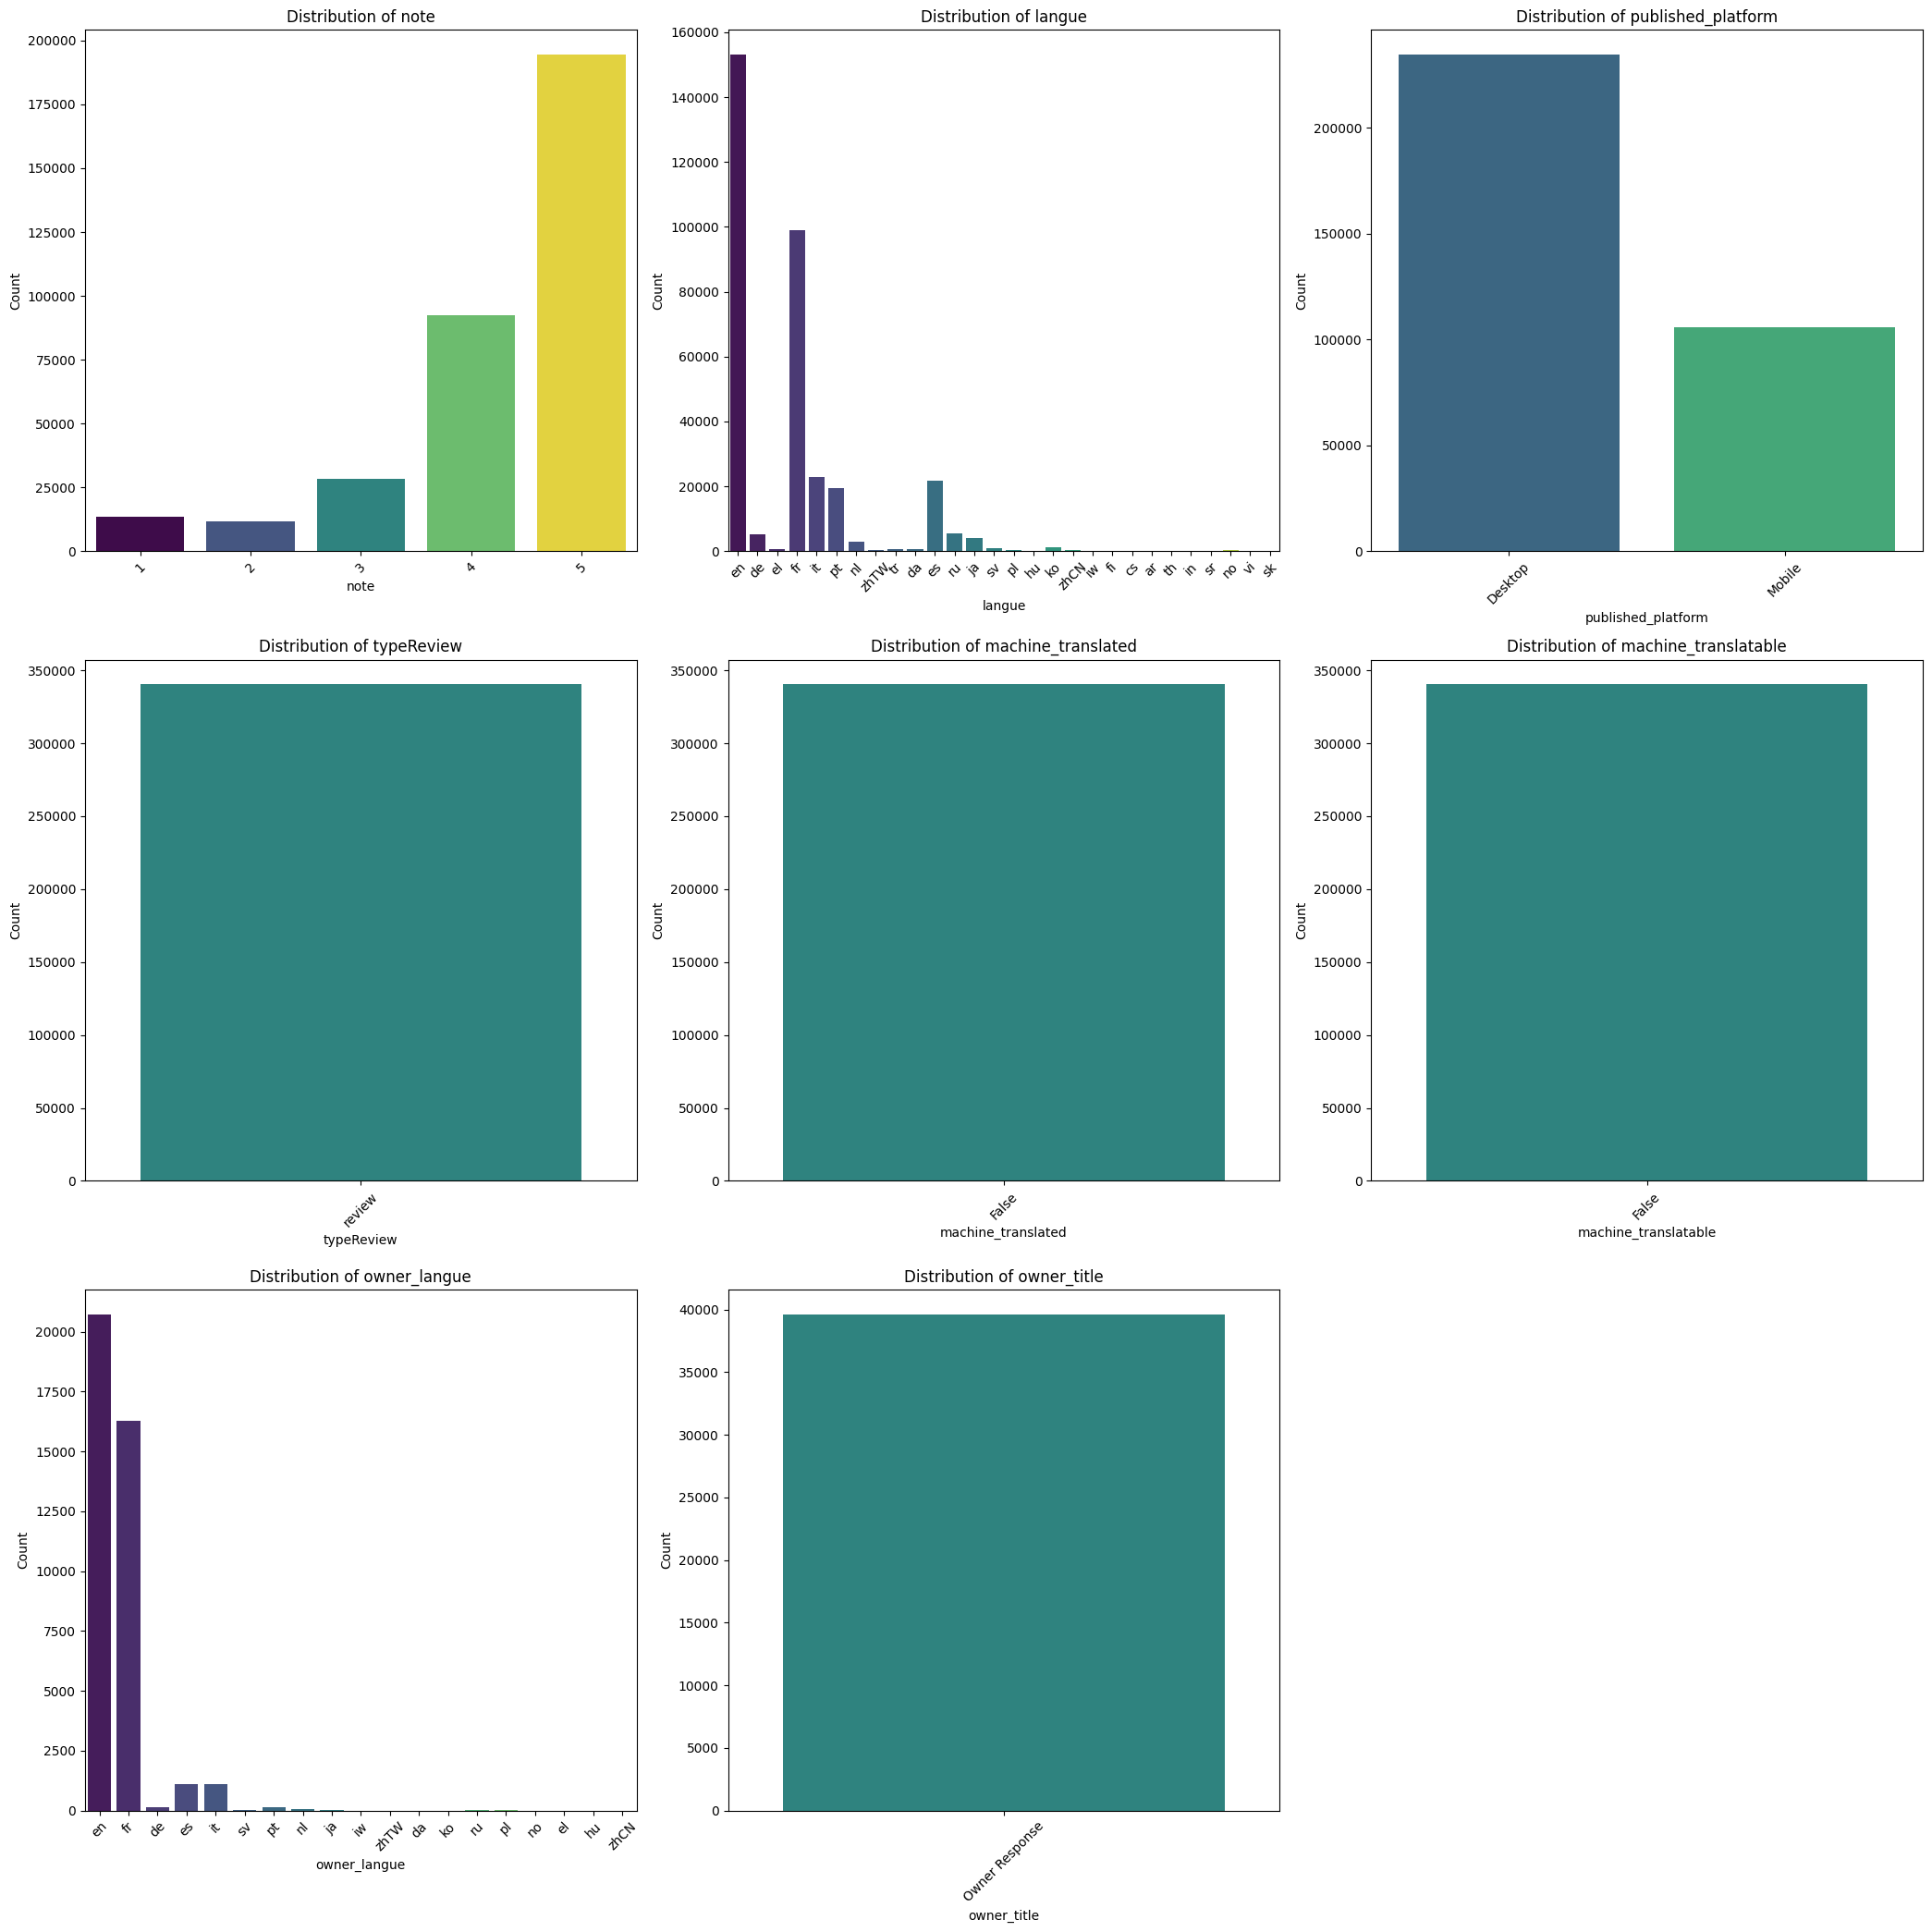

In [ ]:
num_plots = len(discrete_columns)
if num_plots == 0:
    print(f"No columns with less than {max_unique_values} unique non-numeric values to plot.")
else:
    # Determine the grid size for subplots
    ncols = 3  # Maximum 3 plots per row
    nrows = math.ceil(num_plots / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7, nrows * 7))

    # Flatten the axes array for easy iteration, regardless of its original shape
    axes = axes.flatten()

    for i, col in enumerate(discrete_columns):
        sns.countplot(data=reviews_df, x=col, palette='viridis', hue=col, legend=False, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide any unused subplots if the number of plots is not a perfect multiple of ncols
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [ ]:
for col in non_discrete_columns:
    print(f"{col:20}:", reviews_df[col].nunique())
    # print(reviews_df[col].value_counts())

id                  : 340385
idplace             : 2161
titre               : 253942
idauteur            : 255205
review              : 340274
date_review         : 339588
date_visit          : 225
subratings          : 3014
owner_id            : 39641
owner_date_review   : 39632
owner_connection    : 299
owner_responder     : 922
owner_response      : 36101


Convert dates to datetime objects

In [ ]:
reviews_df["date_review"] = pd.to_datetime(reviews_df["date_review"], format="%d/%m/%Y %H:%M:%S")
reviews_df["date_visit"] = pd.to_datetime(reviews_df["date_visit"], format="%Y-%m")

Select only english reviews

In [ ]:
en_reviews_mask = (reviews_df.langue == "en")
en_reviews_df = reviews_df[en_reviews_mask]

Let's keep only places with a minimum number of reviews for training purpose

In [ ]:
reviews_per_place = 4

In [ ]:
satistying_places_df = (
    en_reviews_df
    .groupby("idplace")
    .agg(
        reviews_count=("review", "count"),
        review=("review", pd.Series),
        date_review=("date_review", pd.Series)
    )
    .query(f"reviews_count >= {reviews_per_place}")
    .reset_index()
    .explode(["review", "date_review"])
    .reset_index(drop=True)
)

satistying_places_df = satistying_places_df.drop(columns=["reviews_count"])
satistying_places_df.head()

,idplace,review,date_review
0,188467,Personally I think it is the most beautiful sq...,2020-09-23 11:14:11
1,188467,We walked through this lovely park but did not...,2020-09-11 07:52:32
2,188467,We come back to this huge square every time we...,2020-07-05 03:16:32
3,188467,The most beautiful square in Paris has a stran...,2020-05-31 19:36:17
4,188467,"Lovely architecture, looks different again to ...",2020-03-11 06:16:38


In [ ]:
(
    satistying_places_df
    .groupby("idplace")
    .agg(
        reviews_count=("review", "count"),
    )
).describe()

,reviews_count
count,1160.000000
mean,130.985345
std,1039.715559
min,4.000000
25%,9.000000
50%,21.000000
75%,78.250000
max,33878.000000


75% of the places in the dataset has at most 78 reviews approximately while the place with the highest number of reviews is nearly around 34k reviews.

Let's select the 100 most recent ones.

In [ ]:
n_reviews_train = 100

recent_reviews_df = (
    satistying_places_df
    .sort_values(by="date_review", ascending=False)
    .groupby("idplace")
    .agg(
        review=("review", lambda s: s.iloc[:n_reviews_train]),
        date_review=("date_review", lambda s: s.iloc[:n_reviews_train])
    )
    .reset_index()
    .explode(["review", "date_review"])
    .reset_index(drop=True)
)

In [ ]:
recent_reviews_df["date_review"].describe()

,date_review
count,46780
mean,2018-01-02 13:14:58.273792
min,2002-04-24 02:00:00
25%,2016-10-20 14:25:04.500000
50%,2018-08-18 15:30:25.500000
75%,2019-08-13 10:03:17.249999872
max,2021-05-26 14:46:22


In [ ]:
recent_reviews_df = recent_reviews_df.drop(columns=["date_review"])

In [ ]:
(
    recent_reviews_df
    .groupby("idplace")
    .agg(
        reviews_count=("review", "count"),
    )
).describe()

,reviews_count
count,1160.000000
mean,40.327586
std,37.279319
min,4.000000
25%,9.000000
50%,21.000000
75%,78.250000
max,100.000000


## Split dataset

In [ ]:
places = recent_reviews_df["idplace"].unique()

print(f"Number of places: {len(places)}")

Number of places: 1160


In [ ]:
train_places, test_places = train_test_split(places, test_size=0.5, random_state=42)

print(f"Train size: {len(train_places)}")
print(f"Test size: {len(test_places)}")

Train size: 580
Test size: 580


In [ ]:
train_places, val_places = train_test_split(train_places, test_size=0.2, random_state=42)

print(f"Train size: {len(train_places)}")
print(f"Validation size: {len(val_places)}")

Train size: 464
Validation size: 116


In [ ]:
train_df = recent_reviews_df.loc[recent_reviews_df["idplace"].isin(train_places)]
val_df = recent_reviews_df.loc[recent_reviews_df["idplace"].isin(val_places)]
test_df = recent_reviews_df.loc[recent_reviews_df["idplace"].isin(test_places)]

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (17592, 2)
Validation shape: (5357, 2)
Test shape: (23831, 2)


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17592 entries, 100 to 46763
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   idplace  17592 non-null  int64 
 1   review   17592 non-null  object
dtypes: int64(1), object(1)
memory usage: 412.3+ KB


## Reviews embeddings

In [ ]:
import re
import time
import random
import pickle
from collections import defaultdict

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import Sampler

from transformers import AutoModel, AutoTokenizer
from safetensors.torch import save_file, load_file

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [ ]:
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME, device_map=device)
encoder = AutoModel.from_pretrained(EMBEDDING_MODEL_NAME, device_map=device)

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def mean_pooling(model_output, attention_mask):
    """
    Mean Pooling - Take attention mask into account for correct averaging
    """
    token_embeddings = model_output[0] # First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

In [ ]:
BATCH_SIZE = 32

In [ ]:
def compute_embeddings(tokenizer, encoder, reviews, *, device):
    tokens = tokenizer(
        reviews,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

    with torch.no_grad():
        embs = encoder(
            input_ids=tokens["input_ids"].to(device),
            attention_mask=tokens["attention_mask"].to(device)
        )

    pooled_embs = mean_pooling(embs, tokens["attention_mask"].to(device))
    normalized_embs = F.normalize(pooled_embs, p=2, dim=1)
    return normalized_embs

In [ ]:
n_samples = len(train_df["review"])
embeddings = []

for i in range(0, n_samples, BATCH_SIZE):
    chunk_reviews = train_df["review"].iloc[i:i+BATCH_SIZE]
    chunk_embs = compute_embeddings(tokenizer, encoder, chunk_reviews.to_list(), device=device)
    embeddings.extend(chunk_embs)

train_embeddings_df = pd.DataFrame({
    "idplace": train_df["idplace"],
    "embedding": [emb.cpu() for emb in embeddings]
})

In [ ]:
train_embeddings_df.iloc[0, 1].size()

torch.Size([384])

In [ ]:
n_samples = len(val_df["review"])
embeddings = []

for i in range(0, n_samples, BATCH_SIZE):
    chunk_reviews = val_df["review"].iloc[i:i+BATCH_SIZE]
    chunk_embs = compute_embeddings(tokenizer, encoder, chunk_reviews.to_list(), device=device)
    embeddings.extend(chunk_embs)

val_embeddings_df = pd.DataFrame({
    "idplace": val_df["idplace"],
    "embedding": [emb.cpu() for emb in embeddings]
})

In [ ]:
n_samples = len(test_df["review"])
embeddings = []

for i in range(0, n_samples, BATCH_SIZE):
    chunk_reviews = test_df["review"].iloc[i:i+BATCH_SIZE]
    chunk_embs = compute_embeddings(tokenizer, encoder, chunk_reviews.to_list(), device=device)
    embeddings.extend(chunk_embs)

test_embeddings_df = pd.DataFrame({
    "idplace": test_df["idplace"],
    "embedding": [emb.cpu() for emb in embeddings]
})

In [ ]:
train_embeddings_df.to_pickle(f"{data_folder}/train_embeddings.pickle")
val_embeddings_df.to_pickle(f"{data_folder}/val_embeddings.pickle")
test_embeddings_df.to_pickle(f"{data_folder}/test_embeddings.pickle")

In [ ]:
train_embeddings_df = pd.read_pickle(f"{data_folder}/train_embeddings.pickle")
val_embeddings_df = pd.read_pickle(f"{data_folder}/val_embeddings.pickle")
test_embeddings_df = pd.read_pickle(f"{data_folder}/test_embeddings.pickle")

# Recommender Setup

## Attention Aggregator Encoder

Dataset class for each item a sampling of k reviews' embeddings associated to an idplace

In [ ]:
class TouristPlaceDataset(Dataset):
    def __init__(self, df, group_col="idplace", col="embedding", k=10, tensor=True):
        """
        df : DataFrame
        k : Number of reviews to sample
        """
        self.k = k
        # Mapping from place to their list of reviews
        self.place_to_choices = df.groupby(group_col)[col].apply(list).to_dict()
        self.place_ids = list(self.place_to_choices.keys())
        self.tensor = tensor

    def __len__(self):
        return len(self.place_ids)

    def __getitem__(self, idx):
        place_id = self.place_ids[idx]
        all_choices = self.place_to_choices[place_id]

        # Sampling strategy
        if len(all_choices) >= self.k:
            # Sampling without repetition
            sampled_choices = random.sample(all_choices, self.k)
        else:
            # Sampling with repetition if place doesn't have enough reviews (len < k)
            sampled_choices = random.choices(all_choices, k=self.k)

        # Convert to tensor if required
        if self.tensor:
            sampled_choices = torch.tensor(np.array(sampled_choices), dtype=torch.float)

        # Features: sampled_choices (sampled)
        # Label: place_id
        return sampled_choices, place_id

In [ ]:
class TripletsBatchSampler(Sampler):
    def __init__(self, labels, n_places_per_batch, n_instances_per_place):
        self.labels = labels # List of place_id attributed to indices in dataset
        self.n_places_per_batch = n_places_per_batch
        self.n_instances_per_place = n_instances_per_place
        self.batch_size = n_places_per_batch * n_instances_per_place

        # Mapping : {place_id: [indices_to_access_it_from_dataset...]}
        self.place_to_indices = {}
        for idx, label in enumerate(self.labels):
            if label not in self.place_to_indices:
                self.place_to_indices[label] = []
            self.place_to_indices[label].append(idx)

        self.unique_places = list(self.place_to_indices.keys())

    def __iter__(self):
        while True:
            batch = []
            # Randomly select `n_places_per_batch` places
            selected_places = random.sample(self.unique_places, self.n_places_per_batch)

            for place in selected_places:
                indices = self.place_to_indices[place]
                # Randomly select `n_instances_per_place` instances for current place (with replacement if necessary)
                replace = len(indices) < self.n_instances_per_place
                selected_indices = np.random.choice(indices, self.n_instances_per_place, replace=replace)
                # Add indices to batch
                batch.extend(selected_indices)

            yield batch

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = TouristPlaceDataset(train_embeddings_df)
val_dataset = TouristPlaceDataset(val_embeddings_df)

batch_sampler = TripletsBatchSampler(
    labels=train_dataset.place_ids,
    n_places_per_batch=8,
    n_instances_per_place=4
)

train_dataloader = DataLoader(train_dataset, batch_sampler=batch_sampler)

In [ ]:
# Item 0 is a tuple (features, label) from which we take the first element
val_dataset[0][0].size() # k x EMBED_DIM

torch.Size([10, 384])

In [ ]:
# Features
len(next(iter(train_dataloader))[0]) # BATCH_SIZE x k x EMBED_DIM

32

In [ ]:
# Labels
next(iter(train_dataloader))[1].size() # BATCH_SIZE

torch.Size([32])

Each batch is composed of repetitions of the same index for each of the places. Because, using this same index, we can obtain a random combination of its reviews.

In [ ]:
next(iter(train_dataloader))[1]

tensor([ 1336101,  1336101,  1336101,  1336101,  1390891,  1390891,  1390891,
         1390891, 15010883, 15010883, 15010883, 15010883,  3343951,  3343951,
         3343951,  3343951, 18977342, 18977342, 18977342, 18977342, 11457915,
        11457915, 11457915, 11457915, 17419683, 17419683, 17419683, 17419683,
         1929987,  1929987,  1929987,  1929987])

Attention Aggregator Encoder Model

In [ ]:
class AttentionAggregatorEncoder(nn.Module):
    def __init__(self, input_dim, device):
        super().__init__()
        self.device = device

        # Layer learning to score components' importance in reviews' embeddings
        self.attention_weights = nn.Linear(input_dim, 1).to(device)

        # Projection layer
        self.projection = nn.Sequential(
            nn.Linear(input_dim, 256),
            # nn.ReLU(),
            # nn.Linear(256, 128)
        ).to(device)

    def forward(self, x):
        """
        Args:
            x: has a shape (batch_size, k, input_dim)
        Notes:
            k can vary on each passage
        """
        # Importance scores
        scores = self.attention_weights(x) # (batch_size, k, 1)
        weights = F.softmax(scores, dim=1)  # Normalisation over k reviews

        # Weighted Sum : (batch_size, k, 1) * (batch_size, k, input_dim)
        weighted_representation = torch.sum(weights * x, dim=1) # (batch_size, input_dim)

        # Extra projection
        z = self.projection(weighted_representation)

        # Normalization
        embeddings = nn.functional.normalize(z)
        return embeddings

Function to build embeddings for one place based on its reviews

In [ ]:
def build_place_embeddings(model, dataset, chunk_size=64):
    model.eval()

    # Mapping from place to its embedding (numeric signature)
    places_embeddings = {}
    with torch.no_grad():
        for place_id in dataset.place_ids:
            # All reviews for current place
            all_reviews_embeddings = np.array(dataset.place_to_choices[place_id])
            n_reviews = len(all_reviews_embeddings)

            chunk_outputs = []
            for i in range(0, n_reviews, chunk_size):
                # Select reviews for chunk
                chunk = all_reviews_embeddings[i : i + chunk_size]
                x = torch.tensor(chunk, dtype=torch.float).to(model.device).unsqueeze(0)

                # Predict
                pred_embedding = model(x)
                chunk_outputs.append(pred_embedding.squeeze())

            # Aggregate chunks signatures
            if chunk_outputs:
                stacked_chunks = torch.stack(chunk_outputs)
                place_signature = torch.mean(stacked_chunks, dim=0)
                places_embeddings[place_id] = place_signature

    return places_embeddings

Recall@k

In [ ]:
def compute_recall_at_k(model, dataset, k=5, n_samples=1000):
    model.eval()

    # Build places embeddings and stack them in a matrix
    places_embeddings = build_place_embeddings(model, dataset)
    place_ids = list(places_embeddings.keys())
    place_matrix = torch.stack(
        [places_embeddings[p] for p in place_ids]
    )

    correct = 0
    total = 0

    with torch.no_grad():
        for sample_no, (reviews_embeddings, true_place) in enumerate(dataset):
            if sample_no >= n_samples:
                break
            reviews_embeddings = reviews_embeddings.to(model.device)
            batch_embeddings = reviews_embeddings.unsqueeze(0)

            # Predict
            pred_emb = model(batch_embeddings)

            # Similarity score computation
            scores = torch.matmul(place_matrix, pred_emb.squeeze())

            # Top-K places
            top_k_indices = torch.topk(scores, k, dim=0).indices
            top_k_places = [place_ids[i] for i in top_k_indices]

            # Correct if true_place is retrieved in the top-k
            if true_place in top_k_places:
                correct += 1

            total += 1

    # Ratio of correct over total
    return correct / total

Triplet Loss

In [ ]:
class BatchAllTripletLoss(nn.Module):
    def __init__(self, margin=0.2):
        super(BatchAllTripletLoss, self).__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        """
        embeddings: [batch_size, embed_dim] (output of AttentionAggregatorEncoder)
        labels: [batch_size] (places' IDs)
        """
        # Compute euclidian distances (elevated to power 2) matrices
        #     distances[i,j] = ||e_i - e_j||^2 = ||e_i||^2 + ||e_j||^2 - 2(e_i . e_j)
        dot_product = torch.matmul(embeddings, embeddings.t())
        square_norm = torch.diag(dot_product)

        #           ||e_i||^2                + ||e_j||^2                - 2(e_i . e_j)
        distances = square_norm.unsqueeze(1) + square_norm.unsqueeze(0) - 2.0 * dot_product
        distances = F.relu(distances) # Prevent negative distances

        # Mask Construction for triplets (i, j, k)
        # i = anchor, j = positive, k = negative
        # labels[i] == labels[j]
        labels_equal = labels.unsqueeze(0) == labels.unsqueeze(1) # [batch_size, batch_size]
        # i != j (eliminate self-similarity)
        indices_not_equal = ~torch.eye(labels.size(0), dtype=torch.bool, device=labels.device)

        # Positive mask : i != j & labels[i] == labels[j]
        mask_pos = labels_equal & indices_not_equal

        # Negative mask : labels[i] != labels[k]
        mask_neg = ~labels_equal

        # Loss computation
        anchor_positive_dist = distances.unsqueeze(2) # [batch_size, batch_size, 1]
        anchor_negative_dist = distances.unsqueeze(1) # [batch_size, 1, batch_size]

        # Compute `distances[i,j] - distances[i,k] + margin` for all possible combinations of i,j,k
        triplet_loss = anchor_positive_dist - anchor_negative_dist + self.margin # [batch_size, batch_size, batch_size]

        # Apply masks
        mask = mask_pos.unsqueeze(2) & mask_neg.unsqueeze(1) # [batch_size, batch_size, batch_size]
        triplet_loss = triplet_loss * mask.float()

        # We prefer when triplet_loss[i,j,k] < 0, active triplets are those that are positive
        triplet_loss = F.relu(triplet_loss)

        # Mean over active triplets
        num_positive_triplets = (triplet_loss > 1e-16).float().sum()
        final_loss = triplet_loss.sum() / (num_positive_triplets + 1e-16)

        return final_loss

Checkpoint Manager to save best model

In [ ]:
class CheckpointManager:
    def __init__(self, save_dir):
        self.save_dir = save_dir
        self.best_recall = 0.0
        os.makedirs(save_dir, exist_ok=True)

    def save_checkpoint(self, model, epoch, recall):
        epoch_file = os.path.join(self.save_dir, f"epoch_{epoch}.safetensors")
        save_file(model.state_dict(), epoch_file)

    def save_best(self, model, epoch, recall):
        if recall <= self.best_recall:
            return

        print(f"New best Recall@k: {recall:.4f}")
        self.best_recall = recall

        best_file = os.path.join(self.save_dir, f"best.safetensors")
        save_file(model.state_dict(), best_file)


Funtion to train the review encoder model

In [ ]:
def train(
    model, train_dataloader, val_dataset,
    optimizer, criterion,
    num_epochs, max_step_per_epoch,
    checkpoint_manager
):
    history = defaultdict(list)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for batch_idx, (inputs, labels) in enumerate(train_dataloader):
            if batch_idx == max_step_per_epoch:
                break

            # inputs: (batch_size, k, embed_dim)
            # labels: (batch_size)
            inputs, labels = inputs.to(model.device), labels.to(model.device)

            # Forward pass
            optimizer.zero_grad()
            embeddings_projected = model(inputs) # Output: (batch_size, embed_dim)

            # Compute Triplet Loss (Online Mining)
            loss = criterion(embeddings_projected, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Epoch Loss
        epoch_loss = running_loss / max_step_per_epoch

        # Recall@k evaluation
        recall = compute_recall_at_k(
            model,
            val_dataset,
            k=5,
        )

        # Epoch history
        history["loss"].append(epoch_loss)
        history["recall"].append(recall)
        print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {epoch_loss:.4f} - Recall@5: {recall:.4f}")

        # Save epoch
        checkpoint_manager.save_checkpoint(
            model,
            epoch,
            recall
        )

        # Save best
        checkpoint_manager.save_best(
            model,
            epoch,
            recall
        )
    return history


In [ ]:
model = AttentionAggregatorEncoder(384, device)

criterion = BatchAllTripletLoss(margin=0.3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
checkpoint_manager = CheckpointManager("checkpoints")

num_epochs = 5
max_step_per_epoch = 256

start = time.perf_counter()
history = train(
    model, train_dataloader, val_dataset,
    optimizer, criterion,
    num_epochs, max_step_per_epoch,
    checkpoint_manager
)
end = time.perf_counter()

Epoch 1/5 - Loss: 0.0727 - Recall@5: 0.9828
New best Recall@k: 0.9828
Epoch 2/5 - Loss: 0.0603 - Recall@5: 1.0000
New best Recall@k: 1.0000
Epoch 3/5 - Loss: 0.0596 - Recall@5: 1.0000
Epoch 4/5 - Loss: 0.0606 - Recall@5: 0.9914
Epoch 5/5 - Loss: 0.0493 - Recall@5: 1.0000


In [ ]:
train_time = end - start
print(f"Training time: {train_time:.2f} seconds")

Training time: 13.03 seconds


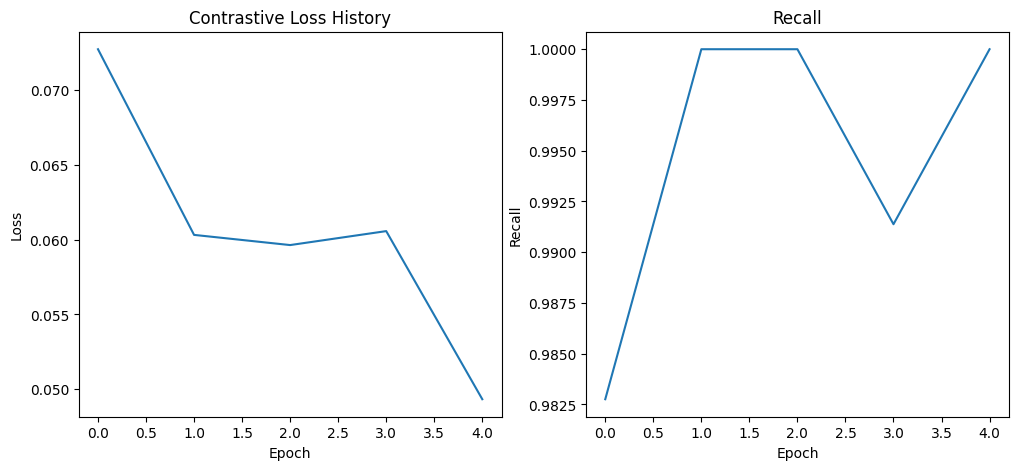

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["loss"])
plt.title("Contrastive Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(history["recall"])
plt.title("Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")

plt.show()

Load model with the highest recall score

In [ ]:
best_model_folder = f"{root_folder}/checkpoints/"
model_archive = f"{root_folder}/checkpoints.zip"

In [ ]:
shutil.make_archive("checkpoints", "zip", best_model_folder)

'/content/checkpoints.zip'

In [ ]:
# Download Checkpoints Archive
# files.download(model_archive)

In [ ]:
with zipfile.ZipFile(model_archive, "r") as zip_ref:
    zip_ref.extractall(best_model_folder)

In [ ]:
state_dict = load_file(f"{best_model_folder}/best.safetensors")

model = AttentionAggregatorEncoder(384, device)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [ ]:
place_to_embedding = build_place_embeddings(
    model,
    train_dataset,
)

In [ ]:
place_to_embedding_backup_path = f"{root_folder}/place_to_embedding.pkl"

In [ ]:
with open(place_to_embedding_backup_path, 'wb') as f:
    pickle.dump(place_to_embedding, f)

In [ ]:
with open(place_to_embedding_backup_path, 'rb') as f:
    place_to_embedding = pickle.load(f)

for place, embedding in place_to_embedding.items():
    place_to_embedding[place] = embedding.to(device)

## Mean Pooling Encoder

In [ ]:
class MeanPoolingEncoder(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.device = device

    def forward(self, x):
        # Mean Pooling
        z = torch.mean(x, dim=1).to(self.device)
        # Normalization
        embeddings = nn.functional.normalize(z)
        return embeddings

In [ ]:
mp_model = MeanPoolingEncoder(device)

mp_place_to_embedding = build_place_embeddings(
    mp_model,
    train_dataset,
)

# Recommender Inference

In [ ]:
attraction_sub_category_df = pd.read_csv(f"{data_folder}/AttractionSubCategorie.csv").set_index("id")
attraction_sub_type_df = pd.read_csv(f"{data_folder}/AttractionSubType.csv").set_index("id")

restaurant_type_df = pd.read_csv(f"{data_folder}/restaurantType.csv").set_index("id")
restaurant_cuisine_df = pd.read_csv(f"{data_folder}/cuisine.csv").set_index("id")
restaurant_dietary_restrictions_df = pd.read_csv(f"{data_folder}/dietary_restrictions.csv").set_index("id")

In [ ]:
trip_df = pd.read_csv(f"{data_folder}/Tripadvisor.csv").set_index("id")

print("Shape:", trip_df.shape)
trip_df.head()

Shape: (3761, 59)


,idTrip,fromId,nom,url,rating,nbAvis,nbAvisRecupere,latitude,longitude,typeR,...,ap_exclusion,ap_inclusions,ap_introduction,ap_primary_supplier_attraction_id,ap_primary_supplier_subtype,ap_primary_ta_geo_id,ap_product_code,ap_product_highlights,ap_product_text,ap_raw
id,,,,,,,,,,,,,,,,,,,,,
188467,187147.0,187070.0,Place des Vosges,https://www.tripadvisor.fr/Attraction_Review-g...,4.108407,5663,5664.0,48.855614,2.365553,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188468,187147.0,187070.0,Rue des Francs Bourgeois,https://www.tripadvisor.fr/Attraction_Review-g...,3.316532,73,73.0,48.858140,2.359880,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188470,187147.0,NaN,Village Saint-Paul,https://www.tripadvisor.fr/Attraction_Review-g...,3.017118,98,98.0,48.853733,2.361295,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188471,187147.0,187144.0,Au Passe-partout,https://www.tripadvisor.fr/Attraction_Review-g...,2.743157,2,2.0,48.853470,2.361600,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188472,187147.0,187070.0,Cloître des Billettes,https://www.tripadvisor.fr/Attraction_Review-g...,2.942987,23,23.0,48.858000,2.354980,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
trip_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3761 entries, 188467 to 23421256
Data columns (total 59 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   idTrip                             3754 non-null   float64
 1   fromId                             201 non-null    float64
 2   nom                                3761 non-null   object 
 3   url                                3697 non-null   object 
 4   rating                             3661 non-null   float64
 5   nbAvis                             3761 non-null   int64  
 6   nbAvisRecupere                     2344 non-null   float64
 7   latitude                           3761 non-null   float64
 8   longitude                          3761 non-null   float64
 9   typeR                              3761 non-null   object 
 10  adresse                            1028 non-null   object 
 11  priceRange                         586 non-null    o

In [ ]:
trip_df.priceRange.value_counts()

,count
priceRange,
££ - £££,396
£,114
€€€,24
€€,21
££££,18
€€€€,13


In [ ]:
def infer_place_category(row):
    category = "Other"
    if pd.notna(row['activiteType']) and str(row['activiteType']).lower() != 'nan':
        category = row['activiteType']
        if row['activiteType'] == 'attraction':
            category = f"Attraction ({row['activiteSubCategorie']})"
    elif pd.notna(row['restaurantType']) and str(row['restaurantType']).lower() != 'nan':
        category = f"Restaurant ({row['restaurantType']})"
    elif pd.notna(row['hotelType']) and str(row['hotelType']).lower() != 'nan':
        category = f"Hotel ({row['hotelType']})"
    return category

trip_df['category'] = trip_df.apply(infer_place_category, axis=1)
trip_df['category'].value_counts()

,count
category,
attractionproduct,2669
Restaurant (10591),542
Attraction (47),105
Attraction (26),66
Other,60
...,...
Hotel (specialty_hotel),1
"Attraction (42,51,56)",1
"Attraction (36,41,42,51)",1


In [ ]:
trip_df.loc[(trip_df['typeR'] == 'H') & pd.notna(trip_df["rating"])].shape

(57, 60)

In [ ]:
trip_df.loc[pd.notna(trip_df["restaurantType"]), "restaurantType"].value_counts()

,count
restaurantType,
10591,542
9909,26
9900,10
"9901,9909",8
"10591,11776",6
"11776,10591",6
16556,6
9901,6
"9909,16556",4


In [ ]:
def get_if_notna(value, getter=lambda x: x, default=None):
    if pd.notna(value):
        return getter(value)
    return default


def get_names_from_specificity_df(df, x):
    return df.loc[[int(f_id) for f_id in x.split(",")], "name"].to_list()


def get_place_eval_metadata(trip_df_row):
    place_metadata = {
        "id": trip_df_row.name,
        "name": trip_df_row["nom"],
        "typeR": trip_df_row["typeR"],
        "price": get_if_notna(trip_df_row["priceRange"]),
        "rating": get_if_notna(trip_df_row["rating"]),
    }

    if trip_df_row["typeR"] == "H":
        place_metadata["type"] = "Hotel"
        place_metadata["category"] = get_if_notna(trip_df_row["hotelType"])

    elif trip_df_row["typeR"] == "R":
        place_metadata["type"] = "Restaurant"
        place_metadata["category"] = get_if_notna(
            trip_df_row["restaurantType"],
            lambda x: get_names_from_specificity_df(restaurant_type_df, x),
            []
        )
        place_metadata["cuisine"] = get_if_notna(
            trip_df_row["restaurantTypeCuisine"],
            lambda x: get_names_from_specificity_df(restaurant_cuisine_df, x),
            []
        )
        place_metadata["dietary_restrictions"] = get_if_notna(
            trip_df_row["restaurantDietaryRestrictions"],
            lambda x: get_names_from_specificity_df(restaurant_dietary_restrictions_df, x),
            []
        )

    elif trip_df_row["typeR"] == "A":
        place_metadata["type"] = "Attraction"
        place_metadata["sub_category"] = get_if_notna(
            trip_df_row["activiteSubCategorie"],
            lambda x: get_names_from_specificity_df(attraction_sub_category_df, x),
            []
        )
        place_metadata["sub_type"] = get_if_notna(
            trip_df_row["activiteSubType"],
            lambda x: get_names_from_specificity_df(attraction_sub_type_df, x),
            []
        )

    elif trip_df_row["typeR"] == "AP":
        place_metadata["type"] = "Attraction Product"
    return place_metadata

In [ ]:
eval_metadata = trip_df.apply(get_place_eval_metadata, axis=1)
eval_metadata_df = pd.DataFrame(eval_metadata.tolist()).set_index("id")

print("Shape:", eval_metadata_df.shape)
eval_metadata_df.head()

Shape: (3761, 10)


,name,typeR,price,rating,type,sub_category,sub_type,category,cuisine,dietary_restrictions
id,,,,,,,,,,
188467,Place des Vosges,A,None,4.108407,Attraction,[Sites touristiques],[Sites et monuments],NaN,NaN,NaN
188468,Rue des Francs Bourgeois,A,None,3.316532,Attraction,[Sites touristiques],[Sites et monuments],NaN,NaN,NaN
188470,Village Saint-Paul,A,None,3.017118,Attraction,"[Shopping, Sites touristiques, Autre]","[Quartiers, Boutiques de cadeaux ou spécialisées]",NaN,NaN,NaN
188471,Au Passe-partout,A,None,2.743157,Attraction,[Shopping],[Magasins d'antiquités],NaN,NaN,NaN
188472,Cloître des Billettes,A,None,2.942987,Attraction,[Sites touristiques],[Sites sacrés et religieux],NaN,NaN,NaN


In [ ]:
def recommend(
    model, tokenizer, encoder,
    place_to_embedding,
    x_reviews,
    k=5,
):
    embeddings = compute_embeddings(tokenizer, encoder, x_reviews, device=model.device)

    with torch.no_grad():
        pred_embedding = model(embeddings.unsqueeze(0))
    pred_embedding = pred_embedding.squeeze()

    scores = {}
    for place, place_emb in place_to_embedding.items():
        scores[place] = torch.dot(pred_embedding, place_emb.to(model.device))

    top_k = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]
    return top_k

In [ ]:
def recommend_from_embeddings(
    model,
    place_to_embedding,
    x_embeddings,
    k=5,
):
    with torch.no_grad():
        pred_embedding = model(x_embeddings.unsqueeze(0).to(model.device))
    pred_embedding = pred_embedding.squeeze()

    scores = {}
    for place, place_emb in place_to_embedding.items():
        scores[place] = torch.dot(pred_embedding, place_emb)

    top_k = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]
    return top_k

Test Dataset

In [ ]:
test_dataset = TouristPlaceDataset(test_df, col="review", tensor=False)

Mean Pooling Inference

In [ ]:
x_idx = np.random.choice(len(test_dataset), 1)[0]
x_reviews, x_place_id = test_dataset[x_idx]

top_k = recommend(
    mp_model, tokenizer, encoder,
    mp_place_to_embedding, x_reviews,
)

place_metadata = eval_metadata_df.loc[x_place_id]
metadata_relevance_mask = pd.notna(place_metadata)

print(f"Top {len(top_k)} recommandations for:")
print(place_metadata[metadata_relevance_mask])

top_k_ids = [p_id for p_id, _ in top_k]
eval_metadata_df.loc[top_k_ids].dropna(axis=1, how="all")

Top 5 recommandations for:
name      Déjeuner-croisière sur la Seine avec repas gas...
typeR                                                    AP
rating                                                  4.0
type                                     Attraction Product
Name: 14174044, dtype: object


,name,typeR,rating,type
id,,,,
11979679,Croisière déjeuner Seine Bateaux avec musique ...,AP,4.5,Attraction Product
11446381,Croisière sur la Seine avec repas de trois pla...,AP,4.0,Attraction Product
11450393,Billets et sièges VIP Paris Moulin Rouge avec ...,AP,4.5,Attraction Product
11452714,Croisière touristique sur la Seine avec les Ba...,AP,3.5,Attraction Product
11449851,Paris : croisière sur la Seine avec dégustatio...,AP,4.5,Attraction Product


Attention Aggregation Inference

In [ ]:
x_idx = np.random.choice(len(test_dataset), 1)[0]
x_reviews, x_place_id = test_dataset[x_idx]

top_k = recommend(
    model, tokenizer, encoder,
    place_to_embedding, x_reviews,
)

place_metadata = eval_metadata_df.loc[x_place_id]
metadata_relevance_mask = pd.notna(place_metadata)

print(f"Top {len(top_k)} recommandations for:")
print(place_metadata[metadata_relevance_mask])

top_k_ids = [p_id for p_id, _ in top_k]
eval_metadata_df.loc[top_k_ids].dropna(axis=1, how="all")

Top 5 recommandations for:
name      Tournée de photoshoot à Paris avec un photogra...
typeR                                                    AP
rating                                                  5.0
type                                     Attraction Product
Name: 14943088, dtype: object


,name,typeR,rating,type
id,,,,
15304777,Séance de photographie privée de vacances avec...,AP,5.0,Attraction Product
15154101,TOUR EIFFEL – Tour photographique d’une durée ...,AP,5.0,Attraction Product
13346619,Séance photo à Paris pour les familles et les ...,AP,5.0,Attraction Product
12471503,Visite privée: Visite personnelle de photograp...,AP,5.0,Attraction Product
11473660,Atelier de perfectionnement,AP,5.0,Attraction Product


In [ ]:
x_reviews = [
    "A peaceful historic museum with beautiful paintings and quiet galleries"
]

top_k = recommend(
    model, tokenizer, encoder,
    place_to_embedding, x_reviews,
)

print(f"Top {len(top_k)} recommandations:")
top_k_ids = [p_id for p_id, _ in top_k]
eval_metadata_df.loc[top_k_ids].dropna(axis=1, how="all")

Top 5 recommandations:


,name,typeR,rating,type,sub_category,sub_type
id,,,,,,
13571341,Visite du musée d'Orsay en petit groupe de 2 h...,AP,5.000000,Attraction Product,NaN,NaN
11459793,Excursion guidée semi-privée avec accès coupe-...,AP,5.000000,Attraction Product,NaN,NaN
11460549,Entrée coupe-file au Musée d'Orsay et visite p...,AP,5.000000,Attraction Product,NaN,NaN
4749786,Musée de la Sculpture en Plein Air,A,2.924928,Attraction,[Sites touristiques],[Sites et monuments]
12133160,Billet coupe-file et visite guidée privée au L...,AP,5.000000,Attraction Product,NaN,NaN


In [ ]:
user_history = [
    "The museum was very quiet and full of history",
    "I loved the ancient paintings and the architecture",
    "A very peaceful gallery with great exhibitions"
]

top_k = recommend(
    model, tokenizer, encoder,
    place_to_embedding, user_history,
)

print(f"Top {len(top_k)} recommandations:")
top_k_ids = [p_id for p_id, _ in top_k]
eval_metadata_df.loc[top_k_ids].dropna(axis=1, how="all")

Top 5 recommandations:


,name,typeR,rating,type,sub_category,sub_type
id,,,,,,
11460549,Entrée coupe-file au Musée d'Orsay et visite p...,AP,5.000000,Attraction Product,NaN,NaN
11459793,Excursion guidée semi-privée avec accès coupe-...,AP,5.000000,Attraction Product,NaN,NaN
4749786,Musée de la Sculpture en Plein Air,A,2.924928,Attraction,[Sites touristiques],[Sites et monuments]
13571341,Visite du musée d'Orsay en petit groupe de 2 h...,AP,5.000000,Attraction Product,NaN,NaN
1022207,Musee de la Magie,A,2.973078,Attraction,[Musées],[Musées spécialisés]


# Recommender Evaluation

## Ranking Error metric

In [ ]:
def multivalues_lmatch(a_list, b_list):
    """
    Check if at least one element of a_list is in b_list
    """
    # Convert a_list as a set
    try:
        a_set = set(a_list)
    except TypeError: # Not an iterable
        a_set = set([a_list])

    # Convert b_list as a set
    try:
        b_set = set(b_list)
    except TypeError:
        b_set = set([b_list])

    # True if a_set is empty
    if len(a_set) == 0:
        return True

    # Otherwise, check if the intersection has at least one element
    return len(a_set & b_set) > 0


def approximate_match(a, b, margin=1):
    return bool(max(0, 1 - abs(a - b) / (margin + 1)))


class TouristPlaceSimiliratyEvaluator:
    def __init__(self, level, depth=1, seq_depends=True):
        """
        Args:
            level (int): level of the comparison (1, 2)
            depth (int): depth of the comparison
            seq_depends (bool): if True, the comparison is sequence dependent
        """
        self.level = level
        self.depth = depth
        self.seq_depends = seq_depends

    @classmethod
    def run_similarity_checks(cls, input_metadata, reco_metadata):
        """
        Run similarity checks on input and reco metadata
        """
        checks = []
        if input_metadata["typeR"] == "H":
            checks = [
                input_metadata["type"] == reco_metadata["type"], # same type
                input_metadata["price"] == reco_metadata["price"], # same price
                approximate_match(input_metadata["rating"], reco_metadata["rating"]), # approximate match for rating
            ]

        if input_metadata["typeR"] == "R":
            checks = [
                input_metadata["type"] == reco_metadata["type"], # same type
                multivalues_lmatch(input_metadata["cuisine"], reco_metadata["cuisine"]), # same cuisine
                input_metadata["price"] == reco_metadata["price"], # same price
                multivalues_lmatch(input_metadata["dietary_restrictions"], reco_metadata["dietary_restrictions"]), # same dietary restrictions
                approximate_match(input_metadata["rating"], reco_metadata["rating"]), # approximate match for rating
            ]

        if input_metadata["typeR"] in ("A", "AP"):
            checks = [
                input_metadata["type"] == reco_metadata["type"], # same type
                multivalues_lmatch(input_metadata["sub_category"], reco_metadata["sub_category"]), # same sub-category
                multivalues_lmatch(input_metadata["sub_type"], reco_metadata["sub_type"]), # same sub-type
                approximate_match(input_metadata["rating"], reco_metadata["rating"]), # approximate match for rating
            ]
        return checks


    def compare_place_level_1(self, input_metadata, reco_metadata):
        """
        Compare two places based on their metadata (Level 1)
        """
        return input_metadata["typeR"] == reco_metadata["typeR"]


    def compare_place_level_2(self, input_metadata, reco_metadata):
        """
        Compare two places based on their metadata (Level 2)
        """
        checks = self.run_similarity_checks(input_metadata, reco_metadata)

        if not self.seq_depends:
            return sum(checks) >= min(self.depth, len(checks))

        for check_no, check in enumerate(checks):
            if check_no == self.depth:
                break
            if not check:
                return False
        return True

    def __call__(self, input_metadata, reco_metadata):
        if self.level == 1:
            return self.compare_place_level_1(input_metadata, reco_metadata)
        if self.level == 2:
            return self.compare_place_level_2(input_metadata, reco_metadata)
        raise ValueError(f"Invalid level: {self.level}")

In [ ]:
def ranking_error_metric(input_id, top_ids, compare_place):
    for idx, reco_id in enumerate(top_ids):
        input_metadata = eval_metadata_df.loc[input_id]
        reco_metadata = eval_metadata_df.loc[reco_id]
        if compare_place(input_metadata, reco_metadata):
            return idx
    return len(top_k)

Same metadata everywhere

In [ ]:
a_id = 208967
a_metadata = eval_metadata_df.loc[a_id]

a_metadata

,208967
name,L'ile Aux Images
typeR,A
price,None
rating,2.879039
type,Attraction
sub_category,"[Shopping, Musées]"
sub_type,[Galeries d'art]
category,NaN
cuisine,NaN
dietary_restrictions,NaN


In [ ]:
b_id = 10105969
b_metadata = eval_metadata_df.loc[b_id]

b_metadata

,10105969
name,Galaxie des Arts
typeR,A
price,None
rating,2.84208
type,Attraction
sub_category,"[Shopping, Musées]"
sub_type,[Galeries d'art]
category,NaN
cuisine,NaN
dietary_restrictions,NaN


In [ ]:
evaluator = TouristPlaceSimiliratyEvaluator(level=1)
print(f"[Level 1] {a_id} x {b_id}:", evaluator(a_metadata, b_metadata))

for depth in range(1, 4):
    evaluator = TouristPlaceSimiliratyEvaluator(level=2, depth=depth)
    print(f"[Level 2 ({depth})] {a_id} x {b_id}:", evaluator(a_metadata, b_metadata))

[Level 1] 208967 x 10105969: True
[Level 2 (1)] 208967 x 10105969: True
[Level 2 (2)] 208967 x 10105969: True
[Level 2 (3)] 208967 x 10105969: True


A place with a different `activiteSubType`

In [ ]:
c_id = 188471
c_metadata = eval_metadata_df.loc[c_id]

c_metadata

,188471
name,Au Passe-partout
typeR,A
price,None
rating,2.743157
type,Attraction
sub_category,[Shopping]
sub_type,[Magasins d'antiquités]
category,NaN
cuisine,NaN
dietary_restrictions,NaN


In [ ]:
evaluator = TouristPlaceSimiliratyEvaluator(level=1)
print(f"[Level 1] {a_id} x {c_id}:", evaluator(a_metadata, c_metadata))

for depth in range(1, 4):
    evaluator = TouristPlaceSimiliratyEvaluator(level=2, depth=depth)
    print(f"[Level 2 ({depth})] {a_id} x {c_id}:", evaluator(a_metadata, c_metadata))

[Level 1] 208967 x 188471: True
[Level 2 (1)] 208967 x 188471: True
[Level 2 (2)] 208967 x 188471: True
[Level 2 (3)] 208967 x 188471: False


With `depth=3`, `b_id` is the first right answer

In [ ]:
top_ids = [c_id, b_id, 188467]

evaluator = TouristPlaceSimiliratyEvaluator(level=2, depth=3)
ranking_error_metric(a_id, top_ids, evaluator)

1

With default depth, `c_id` is fine

In [ ]:
evaluator = TouristPlaceSimiliratyEvaluator(level=2)
ranking_error_metric(a_id, top_ids, evaluator)

0

Evaluation function

In [ ]:
def evaluate(recommender_map, score_fn_map, eval_dataset, n_samples=100, k=10):
    scores = defaultdict(list)
    for sample_no, (x_reviews, true_place_id) in enumerate(eval_dataset):
        # Stop at n_samples iteration
        if sample_no >= n_samples:
            break

        for recommender_name, recommender in recommender_map.items():
            # Get recommended choices for current review
            top_k = recommender(x_reviews, k=k)

            for score_fn_name, score_fn in score_fn_map.items():
                # Compute score
                current_score = score_fn(true_place_id, top_k)
                scores[f"{recommender_name} - {score_fn_name}"].append(current_score)

    # Return all scores
    return scores

In [ ]:
# Level 1
evaluator_1 = TouristPlaceSimiliratyEvaluator(level=1)
ranking_error_scorer_1 = lambda input_id, top_k: ranking_error_metric(input_id, [p_id for p_id, _ in top_k], evaluator_1)

# Level 2 - depth 1
evaluator_2_1 = TouristPlaceSimiliratyEvaluator(level=2, depth=1)
ranking_error_scorer_2_1 = lambda input_id, top_k: ranking_error_metric(input_id, [p_id for p_id, _ in top_k], evaluator_2_1)

# Level 2 - depth 2
evaluator_2_2 = TouristPlaceSimiliratyEvaluator(level=2, depth=2)
ranking_error_scorer_2_2 = lambda input_id, top_k: ranking_error_metric(input_id, [p_id for p_id, _ in top_k], evaluator_2_2)

# Level 2 - depth 3
evaluator_2_3 = TouristPlaceSimiliratyEvaluator(level=2, depth=3)
ranking_error_scorer_2_3 = lambda input_id, top_k: ranking_error_metric(input_id, [p_id for p_id, _ in top_k], evaluator_2_3)

scores_fn_map = {
    "Ranking Error (Level 1)": ranking_error_scorer_1,
    "Ranking Error (Level 2 - Depth 1)": ranking_error_scorer_2_1,
    "Ranking Error (Level 2 - Depth 2)": ranking_error_scorer_2_2,
    "Ranking Error (Level 2 - Depth 3)": ranking_error_scorer_2_3,
}

In [ ]:
attention_aggregator_recommender = lambda x_embeddings, k=5: recommend_from_embeddings(
    model,
    place_to_embedding,
    x_embeddings,
    k=k
)

In [ ]:
recommenders_map = {
    "Attention Aggregator": attention_aggregator_recommender,
}

In [ ]:
scores = evaluate(
    recommenders_map,
    scores_fn_map,
    val_dataset,
)

scores_df = pd.DataFrame(scores)

In [ ]:
scores_df.mean()

,0
Attention Aggregator - Ranking Error (Level 1),0.23
Attention Aggregator - Ranking Error (Level 2 - Depth 1),0.23
Attention Aggregator - Ranking Error (Level 2 - Depth 2),0.55
Attention Aggregator - Ranking Error (Level 2 - Depth 3),0.81


## Relevance Score

In [ ]:
def calculate_relevance_score(input_metadata, reco_metadata, precision_level=4):
    """
    Compute a relevance score which is the ratio of number of similarities to total number of checks
    """
    checks = TouristPlaceSimiliratyEvaluator.run_similarity_checks(input_metadata, reco_metadata)
    score = sum(checks) / min(precision_level, len(checks))
    return score

In [ ]:
relevance_score = calculate_relevance_score(a_metadata, b_metadata)
print("Relevance Score:", relevance_score)

Relevance Score: 1.0


In [ ]:
relevance_score = calculate_relevance_score(a_metadata, c_metadata)
print("Relevance Score:", relevance_score)

Relevance Score: 0.75


In [ ]:
# For each prediction, compute the mean of relevance scores for recommended places regarding input place
relevance_scorer = lambda input_id, top_k: np.mean([
    calculate_relevance_score(
        eval_metadata_df.loc[input_id],
        eval_metadata_df.loc[reco_id]
    )
    for reco_id, _ in top_k
])

# Create score functions map
scores_fn_map = {
    "Relevance Score": relevance_scorer,
}

# Evaluate
results = evaluate(
    recommenders_map,
    scores_fn_map,
    val_dataset,
    n_samples=100
)

# Get overall mean for the entire evaluation
pd.DataFrame(results).mean()

,0
Attention Aggregator - Relevance Score,0.940833


## BM25

In [ ]:
%pip install -q rank_bm25

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from rank_bm25 import BM25Okapi

In [ ]:
# Necessary package downloading
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
def preprocess(text):
    # Lower text
    text = text.lower()
    # Replace punctuation and other non-alphabetic characters by a space
    text = re.sub(r"[^\w\s]", " ", text)

    # Tokenize
    tokens = word_tokenize(text)

    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return tokens

Create corpus

In [ ]:
bm25_corpus_docs_df = (
    train_df
    .groupby("idplace")["review"]
    .apply(lambda x: " ".join(x))
    .reset_index()
)

tokenized_corpus = bm25_corpus_docs_df["review"].apply(preprocess).to_list()

BM25 instance

In [ ]:
bm25 = BM25Okapi(tokenized_corpus)

Inference

In [ ]:
def bm25_recommend(bm25, corpus, x_reviews, k=5):
    # Prepare input
    query = " ".join(x_reviews)
    query_tokens = preprocess(query)

    # Compute scores
    scores = bm25.get_scores(query_tokens)

    # Sorted list of indices to most similar places in corpus
    doc_ids = np.argsort(scores)[::-1][:k]

    # Sorted list of places IDs
    top_k_ids = corpus.iloc[doc_ids]["idplace"].to_list()
    # Top-k Scores
    top_k_scores = scores[doc_ids]

    top_k = list(zip(top_k_ids, top_k_scores))
    return top_k

In [ ]:
x_idx = np.random.choice(len(test_dataset), 1)[0]
x_reviews, x_place_id = test_dataset[x_idx]

top_k = bm25_recommend(bm25, bm25_corpus_docs_df, x_reviews)

place_metadata = eval_metadata_df.loc[x_place_id]
metadata_relevance_mask = pd.notna(place_metadata)

print(f"Top {len(top_k)} recommandations for:")
print(place_metadata[metadata_relevance_mask])

top_k_ids = [p_id for p_id, _ in top_k]
eval_metadata_df.loc[top_k_ids].dropna(axis=1, how="all")

Top 5 recommandations for:
name                                                  Eataly Paris Marais
typeR                                                                   R
price                                                            ££ - £££
rating                                                           3.262716
type                                                           Restaurant
category                                                    [Restaurants]
cuisine                 [Italian, Northern-Italian, Southern-Italian, ...
dietary_restrictions                                [Vegetarian Friendly]
Name: 17332066, dtype: object


,name,typeR,price,rating,type,category,cuisine,dietary_restrictions
id,,,,,,,,
3148807,Assaggio,R,££ - £££,3.849160,Restaurant,[Restaurants],"[Italian, Vegetarian Friendly]",[Vegetarian Friendly]
1092837,Pizza momo,R,£,3.282644,Restaurant,[Restaurants],"[Italian, Pizza, Vegetarian Friendly]",[Vegetarian Friendly]
779433,Fuxia,R,££ - £££,3.319077,Restaurant,[Restaurants],"[Italian, European, Vegetarian Friendly, Vegan...","[Vegetarian Friendly, Vegan Options]"
719053,Le Bucheron,R,££ - £££,3.709678,Restaurant,[Restaurants],"[French, European, Italian, Vegetarian Friendly]",[Vegetarian Friendly]
1025327,Monjul,R,££ - £££,4.255330,Restaurant,[Restaurants],"[French, European, Healthy, Contemporary, Fusi...","[Vegetarian Friendly, Vegan Options]"


## Evaluate BM25 & Compare Recommenders

In [ ]:
# Attention Aggregator
attention_aggregator_recommender = lambda x_reviews, k=5: recommend(
    model, tokenizer, encoder,
    place_to_embedding, x_reviews, k=k
)

# Mean Pooling
mean_pooling_recommender = lambda x_reviews, k=5: recommend(
    mp_model, tokenizer, encoder,
    mp_place_to_embedding, x_reviews, k=k
)

# BM25
bm25_recommender = lambda x_reviews, k=5: bm25_recommend(bm25, bm25_corpus_docs_df, x_reviews, k=k)

recommenders_map = {
    "Attention Aggregator": attention_aggregator_recommender,
    "Mean Pooling": mean_pooling_recommender,
    "BM25": bm25_recommender,
}

In [ ]:
scores_fn_map = {
    "Ranking Error (Level 1)": ranking_error_scorer_1,
    "Ranking Error (Level 2 - Depth 1)": ranking_error_scorer_2_1,
    "Ranking Error (Level 2 - Depth 2)": ranking_error_scorer_2_2,
    "Ranking Error (Level 2 - Depth 3)": ranking_error_scorer_2_3,
    "Relevance Score": relevance_scorer,
}

In [ ]:
scores = evaluate(
    recommenders_map,
    scores_fn_map,
    test_dataset,
)

scores_df = pd.DataFrame(scores)

In [ ]:
scores_means = scores_df.mean()

scores_means

,0
Attention Aggregator - Ranking Error (Level 1),0.110000
Attention Aggregator - Ranking Error (Level 2 - Depth 1),0.110000
Attention Aggregator - Ranking Error (Level 2 - Depth 2),0.800000
Attention Aggregator - Ranking Error (Level 2 - Depth 3),1.400000
Attention Aggregator - Relevance Score,0.902000
Mean Pooling - Ranking Error (Level 1),0.200000
Mean Pooling - Ranking Error (Level 2 - Depth 1),0.200000
Mean Pooling - Ranking Error (Level 2 - Depth 2),0.850000
Mean Pooling - Ranking Error (Level 2 - Depth 3),1.620000
Mean Pooling - Relevance Score,0.850500


In [ ]:
reorganized_df = (
    scores_means
    .rename("value")
    .reset_index()
    .rename(columns={"index": "full_label"})
)

# Split by " - "
reorganized_df[["strategy", "metric"]] = (
    reorganized_df["full_label"]
    .str.split(" - ", n=1, expand=True)
)

reorganized_df = reorganized_df.drop(columns="full_label")

comparable_result_df = reorganized_df.pivot(
    index="metric",
    columns="strategy",
    values="value"
)

comparable_result_df

strategy,Attention Aggregator,BM25,Mean Pooling
metric,,,
Ranking Error (Level 1),0.110,0.340000,0.2000
Ranking Error (Level 2 - Depth 1),0.110,0.340000,0.2000
Ranking Error (Level 2 - Depth 2),0.800,0.850000,0.8500
Ranking Error (Level 2 - Depth 3),1.400,1.370000,1.6200
Relevance Score,0.902,0.883417,0.8505
